# 02 Single Camera Data Pipeline

This notebook implements a PyTorch-compatible data loading pipeline for Project Aria Gen 1 recordings, treating `.vrs` files as indexed image sequences without extracting frames to disk.

### Background

The standard approach to loading video data in deep learning pipelines involves extracting frames as JPEG files before training. However, based on technical analysis, we adopted a **hybrid indexed-access approach** using `VrsDataProvider` directly, avoiding disk overhead while maintaining full random access compatibility with PyTorch's `DataLoader`.

### In this notebook, we will:

1. **Initialize the Data Provider:** Establish a connection with the `.vrs` file using the `projectaria_tools` library.

2. **RGB Stream Indexing:** Extract the full timestamp list for the **RGB camera** stream (`camera-rgb`, StreamId `214-1`) to build a random-access index map.

3. **AriaDataset Class:** Implement a PyTorch `Dataset` with `__len__` and `__getitem__`, supporting optional transforms and returning image tensors with their associated timestamps.

4. **DataLoader & Batch Test:** Instantiate the dataset, configure a `DataLoader` with a custom `collate_fn` for int64 timestamps, and iterate over the first batch.

5. **Batch Visualization:** Display a grid of RGB frames from the first batch to visually confirm correct decoding and alignment.

6. **Benchmark on Data Loading:** Measure the time taken to load and process a batch of RGB frames, demonstrating the efficiency of direct `.vrs` access.

7. **Export `src/aria_dataset.py`:** Refactor the final class into a standalone reusable `.py` module.

8. **Multi-Stream Analysis:** Discuss how the single-stream pipeline can be extended to support multiple streams with minimal changes.

As a sample, we will use `kettle_and_forklift_recording.vrs` located in the local `data/raw/kettle_and_forklift/` directory.

For this notebook, we used as references:
* `projectaria_tools` documentation: https://facebookresearch.github.io/projectaria_tools/docs/intro 
* PyTorch `Dataset` / `DataLoader` documentation: https://pytorch.org/docs/stable/data.html

## 2.1 Initialize the Data Provider

The first step is to establish a connection with the `.vrs` file using the `VrsDataProvider` interface from `projectaria_tools`. 

In this notebook, we will work with `kettle_and_forklift_recording.vrs`, a recording that captures a kettle and a forklift. This file was already inspected and validated in Notebook 01, so it is an already reliable input for building the single-camera data loading pipeline.

In [21]:
import os
from projectaria_tools.core import data_provider

# Define paths to the .vrs file
DATA_DIR = os.path.join("..", "data", "raw", "kettle_and_forklift")
VRS_PATH = os.path.join(DATA_DIR, "kettle_and_forklift_recording.vrs")

print("VRS exists:", os.path.exists(VRS_PATH), "|", VRS_PATH)

VRS exists: True | ..\data\raw\kettle_and_forklift\kettle_and_forklift_recording.vrs


In [22]:
# Initialize the data provider for the .vrs file
if os.path.exists(VRS_PATH):
    provider = data_provider.create_vrs_data_provider(VRS_PATH)
    if provider:
        print("Data provider initialized successfully")
        print(f"Available streams: {len(provider.get_all_streams())}")
    else:
        print("Failed to initialize data provider")
else:
    provider = None
    print("VRS file not found")

Data provider initialized successfully
Available streams: 11


## 2.2 RGB Stream Indexing

To make the `.vrs` recording compatible with PyTorch-style random access, we first need to build an index for the RGB camera stream.

In practice, this means extracting the full list of timestamps for the RGB stream (`camera-rgb`, StreamId `214-1`) and storing them in a simple ordered structure. This timestamp list will act as the reference map used by the dataset: each integer index will correspond to one RGB frame and its associated device-time timestamp.

In [23]:
from projectaria_tools.core import sensor_data

# Ensure the provider is available
if "provider" not in globals() or provider is None:
    raise RuntimeError("Provider is not initialized.")

# Define the expected RGB stream identifier (verified in Notebook 01)
RGB_STREAM_ID_STR = "214-1"

# Resolve the RGB stream object from its string identifier
rgb_candidates = [sid for sid in provider.get_all_streams() if str(sid) == RGB_STREAM_ID_STR]

if len(rgb_candidates) == 0:
    raise RuntimeError(f"RGB stream {RGB_STREAM_ID_STR} not found in the VRS file.")

rgb_stream_id = rgb_candidates[0] # Assuming the first match is the correct stream
rgb_label = provider.get_label_from_stream_id(rgb_stream_id) # get the stream label (Should be "camera-rgb")
rgb_sample_count = provider.get_num_data(rgb_stream_id) # Total number of samples in the RGB stream

print("RGB stream resolved successfully")
print("Stream ID   :", rgb_stream_id)
print("Stream label:", rgb_label)
print("Sample count:", rgb_sample_count)

RGB stream resolved successfully
Stream ID   : 214-1
Stream label: camera-rgb
Sample count: 1551


In [24]:
import numpy as np
import pandas as pd

# Extract all device-time timestamps for the RGB stream
rgb_timestamps_ns = np.empty(rgb_sample_count, dtype=np.int64)

# Iterate through all samples in the RGB stream
for i in range(rgb_sample_count):
    # Read one RGB sample by index
    sample = provider.get_sensor_data_by_index(rgb_stream_id, i)

    # Store the device-time timestamp in nanoseconds
    rgb_timestamps_ns[i] = sample.get_time_ns(sensor_data.TimeDomain.DEVICE_TIME)

# Build a simple index table for inspection and debugging
# The DataFrame index corresponds to the dataset index used by the PyTorch dataset
rgb_index_df = pd.DataFrame(
    {"timestamp_ns": rgb_timestamps_ns},
    index=np.arange(rgb_sample_count, dtype=np.int64),
)

print(f"Extracted {len(rgb_timestamps_ns)} RGB timestamps.")

# Display the first 10 indexed timestamps
print("\nFirst 10 RGB frames (leftmost numbers are dataset indices):")
display(rgb_index_df.head(10))

# Display the last 10 indexed timestamps
print("\nLast 10 RGB frames (leftmost numbers are dataset indices):")
display(rgb_index_df.tail(10))

Extracted 1551 RGB timestamps.

First 10 RGB frames (leftmost numbers are dataset indices):


,timestamp_ns
0,888362615137
1,888395942475
2,888429273512
3,888462600850
4,888495914187
5,888529256600
6,888562584137
7,888595906475
8,888629247100
9,888662564562



Last 10 RGB frames (leftmost numbers are dataset indices):


,timestamp_ns
1541,939721060637
1542,939754387512
1543,939787716887
1544,939821049850
1545,939854370475
1546,939887701512
1547,939921031187
1548,939954362062
1549,939987683725
1550,940021010637


In [25]:
# Check timestamp monotonicity for the RGB stream
rgb_deltas_ns = np.diff(rgb_timestamps_ns)

print("Min delta [ms]   :", rgb_deltas_ns.min() / 1e6 if len(rgb_deltas_ns) > 0 else None)
print("Median delta [ms]:", np.median(rgb_deltas_ns) / 1e6 if len(rgb_deltas_ns) > 0 else None) # Median is more robust to outliers than mean
print("Max delta [ms]   :", rgb_deltas_ns.max() / 1e6 if len(rgb_deltas_ns) > 0 else None) 
print("Strictly increasing:", bool(np.all(rgb_deltas_ns > 0))) # True if all deltas are positive, indicating strictly increasing timestamps

Min delta [ms]   : 33.037587
Median delta [ms]: 33.327338
Max delta [ms]   : 33.6145
Strictly increasing: True


## 2.3 AriaDataset Class

Once the RGB stream has been indexed, we can turn it into a PyTorch `Dataset` so that the `.vrs` recording behaves like a standard image dataset.

In this section, we implement a first version of `AriaDataset` for the RGB camera stream. The dataset uses the timestamp list built in the previous section as its random-access reference, supports an optional transform, and returns one image together with its corresponding device-time timestamp for each index.

In [26]:
import numpy as np
import torch

from PIL import Image
from torch.utils.data import Dataset

In [27]:
# Helper function to recursively convert a candidate object to a valid NumPy image array.
def _candidate_to_numpy_image(candidate):
    """
    Try to convert an arbitrary candidate object into a valid image array (H x W or H x W x C).
    Returns None if conversion fails.
    """
    if candidate is None:
        return None

    # If candidate is a tuple/list, recursively inspect each element.
    if isinstance(candidate, (tuple, list)):
        for item in candidate:
            arr = _candidate_to_numpy_image(item)
            if arr is not None:
                return arr
        return None

    # If candidate is callable, evaluate it first.
    if callable(candidate):
        try:
            return _candidate_to_numpy_image(candidate())
        except Exception:
            return None

    # Try common NumPy conversion methods used by image wrapper objects.
    for attr_name in ["to_numpy_array", "to_numpy", "numpy"]:
        if hasattr(candidate, attr_name):
            try:
                value = getattr(candidate, attr_name)
                arr = value() if callable(value) else value
                arr = np.asarray(arr)
                if arr.ndim in (2, 3) and arr.size > 0:
                    return arr
            except Exception:
                pass

    # Try nested image_data containers.
    if hasattr(candidate, "image_data"):
        try:
            nested = candidate.image_data() if callable(candidate.image_data) else candidate.image_data
            arr = _candidate_to_numpy_image(nested)
            if arr is not None:
                return arr
        except Exception:
            pass

    # Final fallback: direct NumPy conversion.
    try:
        arr = np.asarray(candidate)
        if arr.ndim in (2, 3) and arr.size > 0:
            return arr
    except Exception:
        pass

    return None


In [28]:
# Helper function to extract the image payload from a projectaria_tools sample.
def _extract_image_array_from_sample(sample):
    """
    Extract an RGB image from a projectaria_tools SensorData sample and convert it
    to a NumPy array.
    """
    # Try common accessors exposed by SensorData objects.
    for attr_name in ["image_data_and_record", "image_data", "image"]:
        if hasattr(sample, attr_name):
            value = getattr(sample, attr_name)
            candidate = value() if callable(value) else value
            arr = _candidate_to_numpy_image(candidate)
            if arr is not None:
                return arr

    raise RuntimeError(
        f"Unable to extract a valid image array from sample of type: {type(sample)}"
    )

In [29]:
# Helper function to normalize image layout and convert it to PIL format.
def _numpy_to_pil_image(image_array):
    """
    Convert a NumPy image array to a PIL image.

    Supported layouts:
    - H x W
    - H x W x C
    - C x H x W
    """
    image_array = np.asarray(image_array)

    # Convert channel-first arrays to channel-last when necessary.
    if image_array.ndim == 3 and image_array.shape[0] in (1, 3, 4) and image_array.shape[-1] not in (1, 3, 4):
        image_array = np.transpose(image_array, (1, 2, 0))

    # Normalize dtype to uint8 for PIL compatibility.
    if image_array.dtype != np.uint8:
        image_array = np.clip(image_array, 0, 255).astype(np.uint8)

    # Handle grayscale images.
    if image_array.ndim == 2:
        return Image.fromarray(image_array, mode="L")

    if image_array.ndim == 3:
        if image_array.shape[-1] == 1:
            return Image.fromarray(image_array[..., 0], mode="L")
        if image_array.shape[-1] == 3:
            return Image.fromarray(image_array, mode="RGB")
        if image_array.shape[-1] == 4:
            return Image.fromarray(image_array, mode="RGBA")

    raise RuntimeError(f"Unsupported image shape for PIL conversion: {image_array.shape}")

In [30]:
# Helper function to convert a PIL image into a PyTorch tensor.
def _pil_to_tensor(pil_image):
    """
    Convert a PIL image to a float32 PyTorch tensor in CHW format.
    The tensor is normalized to the [0, 1] range.
    """
    # Force a writable NumPy copy to avoid PyTorch non-writable warning.
    image_array = np.array(pil_image, copy=True)

    # Expand grayscale images to H x W x 1 for consistent tensor conversion.
    if image_array.ndim == 2:
        image_array = image_array[..., None]

    tensor = torch.from_numpy(image_array).permute(2, 0, 1).contiguous().float() / 255.0
    return tensor

In [31]:
class AriaDataset(Dataset):
    """
    PyTorch Dataset for indexed RGB frame access from a Project Aria VRS file.

    Each dataset item returns:
    - image: transformed tensor/image
    - timestamp_ns: device-time timestamp in nanoseconds
    """

    def __init__(self, provider, stream_id, timestamps_ns, transform=None):
        # Store input objects needed for random access.
        self.provider = provider
        self.stream_id = stream_id
        self.timestamps_ns = np.asarray(timestamps_ns, dtype=np.int64)
        self.transform = transform

        # Basic validation for safer usage.
        if self.provider is None:
            raise ValueError("provider must not be None")

        if len(self.timestamps_ns) == 0:
            raise ValueError("timestamps_ns must contain at least one timestamp")

    def __len__(self):
        # The dataset length matches the number of indexed RGB timestamps.
        return len(self.timestamps_ns)

    def __getitem__(self, index):
        # Support tensor indices coming from PyTorch samplers.
        if torch.is_tensor(index):
            index = int(index.item())

        # Enforce valid integer indexing.
        index = int(index)
        if index < 0 or index >= len(self.timestamps_ns):
            raise IndexError(f"Index {index} is out of bounds for dataset of size {len(self.timestamps_ns)}")

        # Retrieve the reference timestamp associated with the dataset index.
        timestamp_ns = int(self.timestamps_ns[index])

        # Read the RGB sample from the VRS provider using index-based access.
        sample = self.provider.get_sensor_data_by_index(self.stream_id, index)

        # Extract the image payload and convert it into a PIL image.
        image_array = _extract_image_array_from_sample(sample)
        pil_image = _numpy_to_pil_image(image_array)

        # Apply an optional transform if provided.
        # Otherwise, convert the PIL image to a default PyTorch tensor.
        if self.transform is not None:
            image = self.transform(pil_image)
        else:
            image = _pil_to_tensor(pil_image)

        return image, timestamp_ns

In [32]:
# Create a first dataset instance for the RGB stream
rgb_dataset = AriaDataset(
    provider=provider,
    stream_id=rgb_stream_id,
    timestamps_ns=rgb_timestamps_ns,
    transform=None,
)

print("Dataset created successfully")
print("Dataset length:", len(rgb_dataset))

# Read one sample to verify the output structure
sample_image, sample_timestamp = rgb_dataset[0]

print("Sample timestamp [ns]:", sample_timestamp)
print("Sample type:", type(sample_image))
print("Sample shape:", tuple(sample_image.shape) if hasattr(sample_image, "shape") else None)

Dataset created successfully
Dataset length: 1551
Sample timestamp [ns]: 888362615137
Sample type: <class 'torch.Tensor'>
Sample shape: (3, 1408, 1408)


### Note on AriaDataset class

The `AriaDataset` class wraps indexed RGB access from a Project Aria `.vrs` file into a standard PyTorch `Dataset` interface.

At a high level, each call to `__getitem__(index)` performs the following steps:

1. Validates and normalizes the input index.
2. Retrieves the corresponding device-time timestamp from the precomputed `timestamps_ns` array.
3. Reads the RGB sample from the VRS provider using index-based access.
4. Extracts the image payload from the sample.
5. Converts the image to PIL format.
6. Applies an optional transform (if provided), otherwise converts the image to a default PyTorch tensor.
7. Returns `(image, timestamp_ns)`.

#### Helper functions used by the class

- **`_candidate_to_numpy_image(candidate)`**  
  Recursively inspects arbitrary objects (including tuples/lists, callables, wrappers, and nested fields) and attempts to convert them into a valid NumPy image array (`H x W` or `H x W x C`).

- **`_extract_image_array_from_sample(sample)`**  
  Extracts the image payload from a Project Aria `SensorData` sample by trying common accessors (`image_data_and_record`, `image_data`, `image`) and delegates conversion to `_candidate_to_numpy_image`.

- **`_numpy_to_pil_image(image_array)`**  
  Normalizes image layout (`HWC` / `CHW` / grayscale), enforces `uint8`, and converts the result to a PIL image (`L`, `RGB`, or `RGBA`).

- **`_pil_to_tensor(pil_image)`**  
  Converts a PIL image into a writable `float32` PyTorch tensor in `CHW` format and normalizes values to `[0, 1]`.


## 2.4 DataLoader & Batch Test

We now want to wrap `AriaDataset` with a PyTorch `DataLoader` to enable mini-batch loading.

We use a custom `collate_fn` to ensure:
- images are stacked into a `B x C x H x W` tensor,
- timestamps are returned as a `torch.int64` tensor.

Then we fetch the first batch and inspect shape, dtype, and timestamp values.

In [33]:
from torch.utils.data import DataLoader

# Custom collate function:
# - stacks image tensors
# - packs timestamps as int64 tensor
def aria_collate_fn(batch):
    images, timestamps_ns = zip(*batch)
    images = torch.stack(images, dim=0)
    timestamps_ns = torch.tensor(timestamps_ns, dtype=torch.int64)
    return images, timestamps_ns

In [35]:
BATCH_SIZE = 8 # variable batch size for testing

# num_workers=0 is the safest option, set as default
rgb_loader = DataLoader(
    dataset=rgb_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    collate_fn=aria_collate_fn,
)

print("DataLoader created successfully")
print("Batch size:", BATCH_SIZE)
print("Num batches:", len(rgb_loader)) # expected to be roof(dataset_length / batch_size)

DataLoader created successfully
Batch size: 8
Num batches: 194


In [ ]:
batch_images, batch_timestamps_ns = next(iter(rgb_loader))

print("First batch loaded successfully")
print("Images type:", type(batch_images)) # we want a torch.Tensor
print("Images shape:", tuple(batch_images.shape)) # expected to be (B, C, H, W)
print("Images dtype:", batch_images.dtype) # expected to be torch.float32

print("Timestamps type:", type(batch_timestamps_ns)) # we want a torch.Tensor of dtype int64
print("Timestamps shape:", tuple(batch_timestamps_ns.shape)) # expected to be the length of the monodimensional tensor 
print("Timestamps dtype:", batch_timestamps_ns.dtype) # expected to be torch.int64

print("First timestamp [ns]:", int(batch_timestamps_ns[0]))
print("Last timestamp [ns]:", int(batch_timestamps_ns[-1]))

First batch loaded successfully
Images type: <class 'torch.Tensor'>
Images shape: (8, 3, 1408, 1408)
Images dtype: torch.float32
Timestamps type: <class 'torch.Tensor'>
Timestamps shape: (8,)
Timestamps dtype: torch.int64
First timestamp [ns]: 888362615137
Last timestamp [ns]: 888595906475


In [ ]:
# Basic monotonicity check inside the first batch for sanity validation. 
# We expect strictly increasing timestamps within a batch.
batch_deltas_ns = torch.diff(batch_timestamps_ns)

print("Batch timestamps strictly increasing:", bool(torch.all(batch_deltas_ns > 0)))
print("Min delta [ms]:", float(batch_deltas_ns.min().item()) / 1e6 if len(batch_deltas_ns) > 0 else None)
print("Median delta [ms]:", float(batch_deltas_ns.median().item()) / 1e6 if len(batch_deltas_ns) > 0 else None)
print("Max delta [ms]:", float(batch_deltas_ns.max().item()) / 1e6 if len(batch_deltas_ns) > 0 else None)

Batch timestamps strictly increasing: True
Min delta [ms]: 33.313337
Median delta [ms]: 33.327338
Max delta [ms]: 33.342413


### Test results summary

All batch tests in this section completed successfully and matched expectations:

- `DataLoader` initialization succeeded.
- The first batch was loaded correctly.
- Image batch format is consistent with PyTorch conventions (`B x C x H x W`).
- Image tensor dtype is `torch.float32`.
- Timestamp batch dtype is `torch.int64` and shape is 1D (`(B,)`).
- Batch timestamps are strictly increasing.
- Inter-frame time deltas are stable (around ~33.3 ms), consistent with ~30 FPS.

Overall, the single-camera RGB pipeline is functioning correctly for indexed access and mini-batch loading.

## 2.5 Batch Visualization

To visually validate the RGB pipeline output, we display a small grid of samples from the first batch.

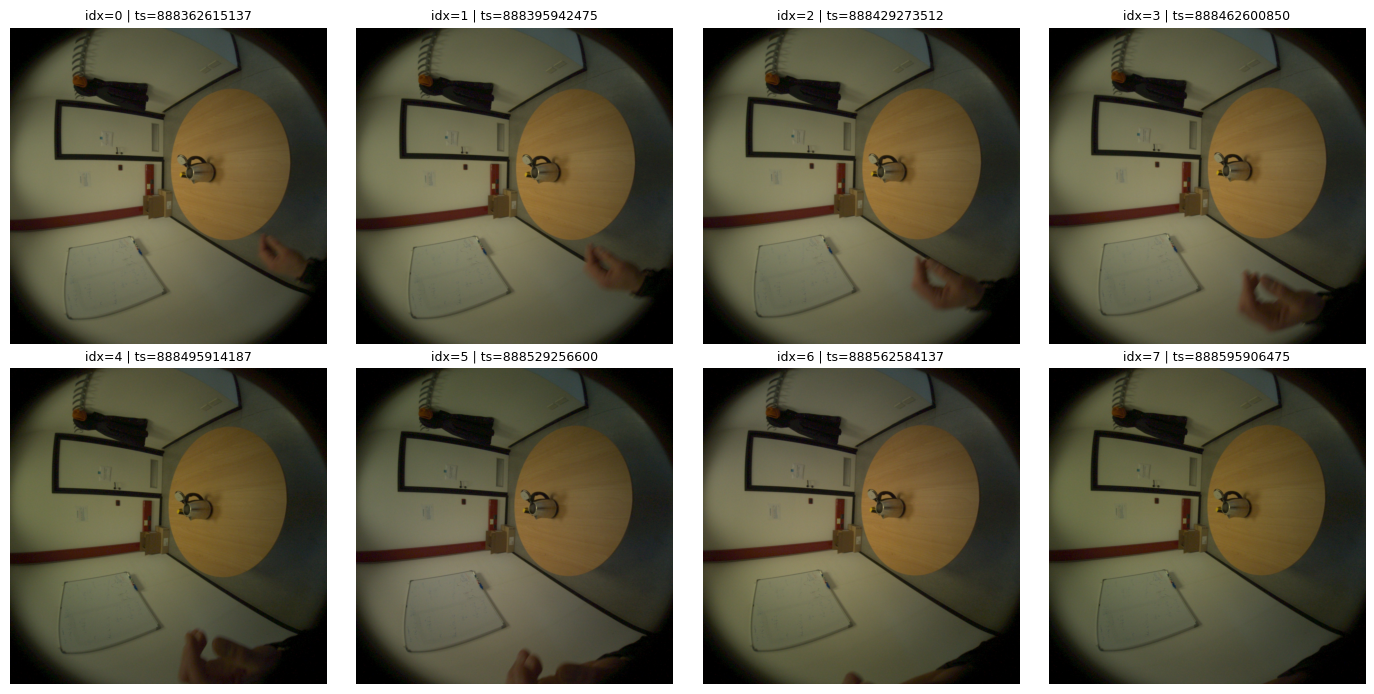

In [ ]:
import math
import matplotlib.pyplot as plt

batch_images, batch_timestamps_ns = next(iter(rgb_loader))

# Visualization function to display a batch of images with their corresponding timestamps in a 4x2 grid.
def show_batch_with_timestamps(images, timestamps_ns, max_items=8, ncols=4, figsize=(14, 7)):
    num_items = min(max_items, images.shape[0])
    nrows = math.ceil(num_items / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.array(axes).reshape(nrows, ncols)

    # Iterate through the batch and display each image with its timestamp.
    for i in range(nrows * ncols):
        r, c = divmod(i, ncols)
        ax = axes[r, c]
        ax.axis("off")

        if i >= num_items:
            continue

        img = images[i].detach().cpu()
        img = img.permute(1, 2, 0).numpy()  # CHW -> HWC
        
        ax.imshow(img)
        ax.set_title(f"idx={i} | ts={int(timestamps_ns[i])}", fontsize=9)

    plt.tight_layout()
    plt.show()

show_batch_with_timestamps(batch_images, batch_timestamps_ns, max_items=8, ncols=4)

### Note on visualization
We notice that the RGB frames are rotated by 90 degrees in the anti-clockwise direction. This is a known issue with the current decoding approach and will be addressed in future iterations of the pipeline. Despite the rotation, the frames are correctly decoded and can be used for downstream tasks after applying a simple rotation transform.

## 2.6 Data Loading Micro-Benchmark

In this section, we measure the practical loading performance of the RGB pipeline built so far.

The goal is to profile the input pipeline, specificaally we want to understand:
- how fast batches are produced,
- how stable batch latency is,
- how many samples/second we can sustain.

### What we benchmark

We run a short benchmark over the `DataLoader` and report:

- **total elapsed time** over a fixed number of batches,
- **batches/sec** and **samples/sec** (throughput),
- **mean batch latency** (ms),
- **p50 / p95 batch latency** (ms).

This gives a concrete estimate of the input throughput ceiling and will help understanding if further optimization is needed for the current setup(`VrsDataProvider` + `AriaDataset` + `DataLoader`)

### Benchmark setup notes

- We keep `num_workers=0` as the default safe setting for Windows.
- We test at least one stable configuration (`shuffle=False`) and optionally compare with `shuffle=True`.
- A short warm-up phase is used to reduce one-time startup effects.


In [38]:
import time
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader

# Benchmark function to measure DataLoader performance with various configurations.
def run_loader_benchmark(
    dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    warmup_batches=2,
    measure_batches=50,
    collate_fn=None,
    ):

    # Create the DataLoader with the specified configuration.
    loader = DataLoader(
        dataset=dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        collate_fn=collate_fn,
    )

    it = iter(loader)

    # Warm-up (ignore timings) used to mitigate startup overhead and stabilize performance.
    for _ in range(warmup_batches):
        try:
            next(it)
        except StopIteration:
            it = iter(loader)
            next(it)

    # Measure the time taken to load a specified number of batches and collect latency statistics.
    latencies_s = []
    measured = 0
    total_samples = 0

    # Iterate through the specified number of batches, measuring the time taken to load each batch.
    t0 = time.perf_counter()
    while measured < measure_batches:
        t_batch_0 = time.perf_counter()
        try:
            images, timestamps = next(it)
        except StopIteration:
            it = iter(loader)
            images, timestamps = next(it)
        t_batch_1 = time.perf_counter()

        latencies_s.append(t_batch_1 - t_batch_0)
        total_samples += int(images.shape[0])
        measured += 1
    t1 = time.perf_counter()

    # Compute overall elapsed time and performance metrics.
    elapsed_s = t1 - t0
    lat_ms = np.array(latencies_s) * 1000.0

    return {
        "batch_size": batch_size,
        "shuffle": shuffle,
        "num_workers": num_workers,
        "warmup_batches": warmup_batches,
        "measure_batches": measure_batches,
        "elapsed_s": elapsed_s,
        "batches_per_s": measure_batches / elapsed_s if elapsed_s > 0 else float("nan"),
        "samples_per_s": total_samples / elapsed_s if elapsed_s > 0 else float("nan"),
        "latency_mean_ms": float(lat_ms.mean()),
        "latency_p50_ms": float(np.percentile(lat_ms, 50)),
        "latency_p95_ms": float(np.percentile(lat_ms, 95)),
    }

In [ ]:
benchmark_results = []
# Define different DataLoader configurations to test.
configs = [
    {"batch_size": 8, "shuffle": False, "num_workers": 0},
    {"batch_size": 8, "shuffle": True,  "num_workers": 0},
]

# Run benchmarks for each configuration and collect results.
for cfg in configs:
    result = run_loader_benchmark(
        dataset=rgb_dataset,
        batch_size=cfg["batch_size"],
        shuffle=cfg["shuffle"],
        num_workers=cfg["num_workers"],
        warmup_batches=2,
        measure_batches=50,
        collate_fn=aria_collate_fn,
    )
    benchmark_results.append(result)

# analyze and display the benchmark results in a DataFrame for easy comparison.
benchmark_df = pd.DataFrame(benchmark_results)
display(benchmark_df)

,batch_size,shuffle,num_workers,warmup_batches,measure_batches,elapsed_s,batches_per_s,samples_per_s,latency_mean_ms,latency_p50_ms,latency_p95_ms
0,8,False,0,2,50,9.587336,5.215213,41.721704,191.739794,186.74995,222.878180
1,8,True,0,2,50,9.967676,5.016214,40.129714,199.347450,194.89070,238.416865


In [41]:
# Print a more human-readable summary of the benchmark results.
for i, row in benchmark_df.iterrows():
    print(f"[Config {i}] batch_size={row['batch_size']}, shuffle={row['shuffle']}, num_workers={row['num_workers']}")
    print(f"  elapsed_s      : {row['elapsed_s']:.3f}")
    print(f"  batches/s      : {row['batches_per_s']:.2f}")
    print(f"  samples/s      : {row['samples_per_s']:.2f}")
    print(f"  latency mean ms: {row['latency_mean_ms']:.2f}")
    print(f"  latency p50 ms : {row['latency_p50_ms']:.2f}")
    print(f"  latency p95 ms : {row['latency_p95_ms']:.2f}")
    print()

[Config 0] batch_size=8, shuffle=False, num_workers=0
  elapsed_s      : 9.587
  batches/s      : 5.22
  samples/s      : 41.72
  latency mean ms: 191.74
  latency p50 ms : 186.75
  latency p95 ms : 222.88

[Config 1] batch_size=8, shuffle=True, num_workers=0
  elapsed_s      : 9.968
  batches/s      : 5.02
  samples/s      : 40.13
  latency mean ms: 199.35
  latency p50 ms : 194.89
  latency p95 ms : 238.42



### Test Results Summary

The micro-benchmark was run with two configurations ( both with `batch_size=8`, `num_workers=0`), comparing `shuffle=False` and `shuffle=True`.

#### Benchmark outcomes

- **Config 0 (`shuffle=False`)**
  - `elapsed_s`: **9.587**
  - `batches_per_s`: **5.22**
  - `samples_per_s`: **41.72**
  - `latency_mean_ms`: **191.74**
  - `latency_p50_ms`: **186.75**
  - `latency_p95_ms`: **222.88**

- **Config 1 (`shuffle=True`)**
  - `elapsed_s`: **9.968**
  - `batches_per_s`: **5.02**
  - `samples_per_s`: **40.13**
  - `latency_mean_ms`: **199.35**
  - `latency_p50_ms`: **194.89**
  - `latency_p95_ms`: **238.42**

#### Analysis

Both configurations are stable and valid.  
In this setup, `shuffle=True` introduces a small overhead: slightly lower throughput and slightly higher latency, especially in the tail (`p95`).

#### What p50 and p95 mean

- **p50 latency (50th percentile)**: the median latency.  
  50% of batches are faster than this value, 50% are slower.
- **p95 latency (95th percentile)**: tail latency.  
  95% of batches complete within this value, while the slowest 5% take longer.

In practice:
- **p50** describes typical batch time.
- **p95** describes worst-case behavior spikes.

## 2.7 Export the Dataset Implementation

Now that we are satisfied with the implementation, we export the finalized `AriaDataset` from the notebook into in the Python script `scripts/aria_dataset.py`.

This makes the data pipeline reusable across notebooks and training scripts, and avoids duplicating helper functions in multiple places.

In [42]:
# check if export worked by importing the module and creating a dataset instance
import os
import sys

# notebook is in /notebooks, module is in project root /scripts
PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

from scripts.aria_dataset import AriaDataset

# Create a new dataset instance using the exported AriaDataset class.
rgb_dataset_exported = AriaDataset(
    provider=provider,
    stream_id=rgb_stream_id,
    timestamps_ns=rgb_timestamps_ns,
    transform=None,
)

# Read one sample to verify the output structure of the exported module.
img, ts = rgb_dataset_exported[0]
print("Exported module OK")
print("Image:", type(img), tuple(img.shape), img.dtype)
print("Timestamp:", type(ts), ts)

Exported module OK
Image: <class 'torch.Tensor'> (3, 1408, 1408) torch.float32
Timestamp: <class 'int'> 888362615137


## 2.8 Moving from single-stream to multi-stream

Moving from a single-stream pipeline to a multi-stream pipeline is relatively simple because the core architecture is already modular and index-based.

### 1) The dataset abstraction is already generic

`AriaDataset` already separates:
- **data access** (`provider.get_sensor_data_by_index(...)`)
- **preprocessing/conversion** (helper functions)
- **PyTorch interface** (`__len__`, `__getitem__`)

So, multi-stream support mainly means extending input configuration and output structure, not rewriting the pipeline.

### 2) Access pattern remains the same

In single-stream mode, one sample is loaded from one stream at a given index.  
In multi-stream mode, the same logic is repeated for multiple stream IDs.

Conceptually:
- single-stream: `index -> one stream sample`
- multi-stream: `index -> N stream samples`

The random-access mechanism is the same.

### 3) Existing helper functions are reusable

Image extraction and conversion helpers already handle multiple sample representations.  
They can be reused for each camera stream without redesigning the preprocessing stack.

### 4) DataLoader integration does not change

`DataLoader` still calls `__getitem__` and receives one item per index.  
Only the returned payload changes (e.g., tuple -> dictionary with multiple streams).  
A custom `collate_fn` can handle this with minimal updates.

### 5) Stable public API reduces refactoring cost

Keeping the class name `AriaDataset` stable allows:
- no import changes in notebooks/scripts,
- gradual extension of the constructor to support multiple stream IDs,
- backward compatibility for current single-stream code.


## Final Results

In this notebook, we built and validated a complete **single-camera data pipeline** for Project Aria Gen 1 recordings, using direct indexed access to `.vrs` data through `VrsDataProvider`.

### What was achieved

- Initialized and validated the recording provider.
- Indexed the RGB stream (`camera-rgb`, `214-1`) with device-time timestamps.
- Implemented a reusable PyTorch-compatible `AriaDataset`.
- Verified end-to-end batching with `DataLoader` and custom `collate_fn`.
- Benchmarked loading throughput and latency (`p50`, `p95`) under different settings.
- Exported the dataset implementation into a reusable Python module.

The pipeline is stable, modular, and ready for reuse.  
Using direct `.vrs` indexed access avoids frame extraction overhead while preserving random-access compatibility with PyTorch.